# NLP Assignment 2

**Student Name:** Abubakar Imran  
**Roll Number:** i23-2589

---

In [11]:
# Initial Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import collections
import os
import json
import math
import random

## 1. Data Loading and Preprocessing

In [12]:
def load_and_tokenize(file_path):
    """
    Reads the file and tokenizes by whitespace.
    """
    if not os.path.exists(file_path):
        return []
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
    return text.split()

def build_vocabulary(tokens, max_vocab_size=10000):
    """
    Builds word2idx and idx2word dictionaries, limiting to max_vocab_size.
    Replaces rare words with <UNK>.
    """
    word_counts = collections.Counter(tokens)
    common_words = word_counts.most_common(max_vocab_size - 1)
    
    word2idx = {"<UNK>": 0}
    idx2word = {0: "<UNK>"}
    
    for word, _ in common_words:
        if word not in word2idx:
            idx = len(word2idx)
            word2idx[word] = idx
            idx2word[idx] = word
            
    return word2idx, idx2word, word_counts

def preprocess_corpus(tokens, word2idx):
    """
    Replaces tokens not in word2idx with <UNK> (index 0).
    """
    return [word2idx.get(token, word2idx["<UNK>"]) for token in tokens]

In [13]:
# Execution
DATA_PATH = "data/cleaned.txt"
tokens = load_and_tokenize(DATA_PATH)
word2idx, idx2word, word_counts = build_vocabulary(tokens, max_vocab_size=10000)
tokenized_corpus = preprocess_corpus(tokens, word2idx)

print(f"Loaded {len(tokens)} tokens.")
print(f"Vocabulary size: {len(word2idx)}")

Loaded 316906 tokens.
Vocabulary size: 10000


## 2. Word2Vec (Skip-gram) from Scratch

In [14]:
from embeddings.word2vec import SkipGramModel

class OptimizedWord2VecDataset(Dataset):
    def __init__(self, corpus, window_size=5):
        # VECTORIZED PAIR GENERATION
        corpus = np.array(corpus, dtype=np.int64)
        centers = []
        contexts = []
        for i in range(1, window_size + 1):
            # Pairs where context is i positions to the right
            centers.append(corpus[:-i])
            contexts.append(corpus[i:])
            # Pairs where context is i positions to the left
            centers.append(corpus[i:])
            contexts.append(corpus[:-i])
            
        self.centers = np.concatenate(centers)
        self.contexts = np.concatenate(contexts)
        print(f"Total training pairs: {len(self.centers)}")

    def __len__(self):
        return len(self.centers)

    def __getitem__(self, idx):
        return self.centers[idx], self.contexts[idx]

In [15]:
# Prepare Noise Distribution for Vectorized Negative Sampling
vocab_size = len(word2idx)
counts = np.array([word_counts.get(idx2word[i], 0) for i in range(vocab_size)])
pow_counts = np.power(counts, 0.75)
neg_probs = torch.tensor(pow_counts / np.sum(pow_counts), dtype=torch.float)

# Hyperparameters
EMBEDDING_DIM = 100
WINDOW_SIZE = 5
NEG_SAMPLES = 10
BATCH_SIZE = 1024 # Increased for better parallelism
EPOCHS = 5
LEARNING_RATE = 0.001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset = OptimizedWord2VecDataset(tokenized_corpus, window_size=WINDOW_SIZE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

model = SkipGramModel(vocab_size, EMBEDDING_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

losses = []
for epoch in range(EPOCHS):
    epoch_loss = 0
    for i, (center, context) in enumerate(dataloader):
        center, context = center.to(device), context.to(device)
        batch_curr = center.size(0)
        
        # VECTORIZED NEGATIVE SAMPLING (VERY FAST)
        neg = torch.multinomial(neg_probs, batch_curr * NEG_SAMPLES, replacement=True)
        neg = neg.view(batch_curr, NEG_SAMPLES).to(device)
        
        pos_score, neg_score = model(center, context, neg)
        
        # SGNS Loss
        loss = -(F.logsigmoid(pos_score).sum() + F.logsigmoid(-neg_score).sum())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        if i % 1000 == 0:
            print(f"Epoch {epoch+1}, Batch {i}, Loss: {loss.item()/batch_curr:.4f}")
            
    avg_loss = epoch_loss / len(dataset)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1} Complete. Average Loss: {avg_loss:.4f}")

Using device: cpu
Total training pairs: 3169030
Epoch 1, Batch 0, Loss: 7.6246
Epoch 1, Batch 1000, Loss: 3.1964
Epoch 1, Batch 2000, Loss: 3.0823
Epoch 1, Batch 3000, Loss: 3.0662
Epoch 1 Complete. Average Loss: 3.3307
Epoch 2, Batch 0, Loss: 3.0577
Epoch 2, Batch 1000, Loss: 2.9874
Epoch 2, Batch 2000, Loss: 2.9970
Epoch 2, Batch 3000, Loss: 2.9865
Epoch 2 Complete. Average Loss: 3.0040
Epoch 3, Batch 0, Loss: 2.9546
Epoch 3, Batch 1000, Loss: 2.9028
Epoch 3, Batch 2000, Loss: 2.9016
Epoch 3, Batch 3000, Loss: 2.9266
Epoch 3 Complete. Average Loss: 2.9272
Epoch 4, Batch 0, Loss: 2.8998
Epoch 4, Batch 1000, Loss: 2.9158
Epoch 4, Batch 2000, Loss: 2.8606
Epoch 4, Batch 3000, Loss: 2.8404
Epoch 4 Complete. Average Loss: 2.8717
Epoch 5, Batch 0, Loss: 2.8452
Epoch 5, Batch 1000, Loss: 2.8016
Epoch 5, Batch 2000, Loss: 2.7858
Epoch 5, Batch 3000, Loss: 2.8070
Epoch 5 Complete. Average Loss: 2.8281


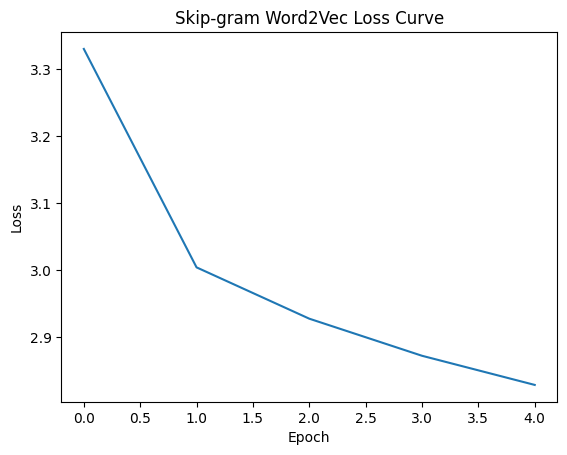

In [16]:
# Finalize and Save
embeddings = model.get_embeddings()
np.save("embeddings/embeddings_w2v.npy", embeddings)

plt.plot(losses)
plt.title("Skip-gram Word2Vec Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()